# Arcsin Kernel GPR and h3 Learnability vs Dataset Size

This notebook:
- draws train/test data from a unit Gaussian in dimension `d = 20`
- uses the target function `y(x) = x[:, 0] + 0.03 * (x[:, 0]**3 - 3*x[:, 0])`
- fits arcsin-kernel GPR for multiple dataset sizes `P` from `d` to `4000`
- computes h3 learnability with a projection-style estimator adapted from your snippet
- plots learnability as a function of `P`

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_float32_matmul_precision('high')
device = torch.device('cpu')#'cuda:1' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [33]:
import subprocess
import tempfile
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'lib').exists() and (p / 'milestones').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
JULIA_EOS = REPO_ROOT / 'julia_lib' / 'eos_fcn3erf.jl'


def compute_theory_lH1T(P: int, d: int, N: int, chi: float, kappa: float, eps: float) -> float:
    """Return theory lH1T scaled by P (matching semi_empirical_effective_ridge_correction.py)."""
    with tempfile.NamedTemporaryFile(suffix='.json', delete=False) as tf:
        out_path = Path(tf.name)

    cmd = [
        'julia',
        str(JULIA_EOS),
        f'--d={int(d)}',
        f'--P={int(P)}',
        f'--n1={int(N)}',
        f'--n2={int(N)}',
        f'--chi={float(chi)}',
        f'--kappa={float(kappa)}',
        f'--epsilon={float(eps)}',
        f'--to={out_path}',
        '--quiet',
    ]

    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
        with open(out_path, 'r') as f:
            data = json.load(f)
        lH1T = data.get('target', {}).get('lH1T', None)
        if lH1T is None:
            raise RuntimeError(f'lH1T missing in solver output for P={P}')
        return float(lH1T) * float(P)
    finally:
        try:
            out_path.unlink(missing_ok=True)
        except Exception:
            pass


def arcsin_kernel_cross(Xa: torch.Tensor, Xb: torch.Tensor, sigma00: float = 1.0, eps: float = 1e-6) -> torch.Tensor:
    """Arcsin kernel between Xa and Xb with configurable sigma[0,0]."""
    d = Xa.shape[1]
    sigma = torch.eye(d, device=Xa.device, dtype=Xa.dtype) / d
    sigma[0, 0] += (-1.0 / d + float(sigma00))

    XXT = (Xa @ sigma @ Xb.T) / d
    nb = torch.sqrt(1.0 + 2.0 * (Xb * sigma.diagonal() * Xb).sum(dim=1) / d)
    na = torch.sqrt(1.0 + 2.0 * (Xa * sigma.diagonal() * Xa).sum(dim=1) / d)
    denom = na[:, None] * nb[None, :]
    arg = 2.0 * XXT / denom
    arg = torch.clamp(arg, -1.0 + eps, 1.0 - eps)
    return (2.0 / math.pi) * torch.arcsin(arg)


def target_fn(X: torch.Tensor) -> torch.Tensor:
    x0 = X[:, 0]
    return x0 + 0.03 * (x0**3 - 3.0 * x0)


def fit_gpr_arcsin(X_train: torch.Tensor, y_train: torch.Tensor, sigma00: float = 1.0, jitter: float = 1e-5):
    K = arcsin_kernel_cross(X_train, X_train, sigma00=sigma00)
    K = K + jitter * torch.eye(K.shape[0], device=K.device, dtype=K.dtype)
    L = torch.linalg.cholesky(K)
    alpha = torch.cholesky_solve(y_train[:, None], L).squeeze(-1)
    return alpha


def predict_gpr_arcsin(X_test: torch.Tensor, X_train: torch.Tensor, alpha: torch.Tensor, sigma00: float = 1.0) -> torch.Tensor:
    K_xt = arcsin_kernel_cross(X_test, X_train, sigma00=sigma00)
    return K_xt @ alpha

In [30]:
def h3_learnability_like_snippet(predict_fn, d: int, device: torch.device, cfg=None):
    """
    Projection-style h3 learnability estimate using the same structure as your snippet,
    adapted to scalar GPR outputs.
    """
    cfg = cfg or {}
    torch.manual_seed(int(cfg['seed'] * 3.14) if 'seed' in cfg else 4324)

    x0 = torch.randn(50000, d, device=device)
    out = predict_fn(x0)

    linear_coeff = (out * x0[:, 0]).mean()
    linear_component = linear_coeff * x0[:, 0]
    h3_comp = (x0[:, 0]**3 - 3.0 * x0[:, 0]) / (6.0**0.5)
    h1_sum = linear_coeff.item()
    remainder = out - linear_component

    proj3_target_sum = (remainder * h3_comp).mean().item()
    y_k = (h3_comp * (x0[:, 0] + 0.03 * h3_comp)).mean().item()
    h3_sum = proj3_target_sum / 0.03

    return {
        'h1_sum': h1_sum,
        'proj3_target_sum': proj3_target_sum,
        'y_k': y_k,
        'h3_learnability': h3_sum,
    }

def h3_learnability_on_test(y_pred: torch.Tensor, X_test: torch.Tensor):
    x0 = X_test[:, 0]
    h3_comp = (x0**3 - 3.0 * x0) / (6.0**0.5)
    linear_coeff = (y_pred * x0).mean()
    linear_component = linear_coeff * x0
    remainder = y_pred - linear_component
    proj3 = (remainder * h3_comp).mean()
    return (proj3 / 0.03).item()

In [34]:
# Experiment config
d = 10
cfg = {'seed': 123}
train_seed = 2026
jitter = 0.1
P_max = 20000

# Theory config for lwT (lH1T) used in effective GPR
N_theory = 1600
chi_theory = 20.0
kappa_theory = 0.1
eps_theory = 0.03

# P from d to P_max (log-spaced, includes endpoints)
P_values = np.unique(np.round(np.geomspace(d, P_max, 14)).astype(int))
if P_values[0] != d:
    P_values = np.insert(P_values, 0, d)
if P_values[-1] != P_max:
    P_values = np.append(P_values, P_max)

# Fixed test set for all P
torch.manual_seed(7)
X_test = torch.randn(50000, d, device=device)
y_test = target_fn(X_test)

results = []
lwt_cache = {}

for P in P_values:
    torch.manual_seed(train_seed + int(P))
    X_train = torch.randn(int(P), d, device=device)
    y_train = target_fn(X_train)

    # Compute config-specific theoretical lwT (= lH1T scaled by P) once per P
    if int(P) not in lwt_cache:
        lwt_cache[int(P)] = compute_theory_lH1T(
            P=int(P),
            d=d,
            N=N_theory,
            chi=chi_theory,
            kappa=kappa_theory,
            eps=eps_theory,
        )
    sigma00_eff = lwt_cache[int(P)]

    alpha = fit_gpr_arcsin(X_train, y_train, sigma00=sigma00_eff, jitter=jitter)

    def predict_fn(X):
        return predict_gpr_arcsin(X, X_train, alpha, sigma00=sigma00_eff)

    with torch.no_grad():
        y_pred = predict_fn(X_test)
        mse = ((y_pred - y_test) ** 2).mean().item()

    h3_proj_stats = h3_learnability_like_snippet(predict_fn, d=d, device=device, cfg=cfg)
    h3_test = h3_learnability_on_test(y_pred, X_test)

    results.append({
        'P': int(P),
        'sigma00_eff': float(sigma00_eff),
        'mse_test': mse,
        'h3_learnability_proj': h3_proj_stats['h3_learnability'],
        'h3_learnability_test': h3_test,
        'h1_sum_proj': h3_proj_stats['h1_sum'],
        'proj3_target_sum': h3_proj_stats['proj3_target_sum'],
        'y_k': h3_proj_stats['y_k'],
    })

results

[{'P': 10,
  'sigma00_eff': 0.6033813741637208,
  'mse_test': 0.2915741503238678,
  'h3_learnability_proj': -1.245479037364324,
  'h3_learnability_test': -1.202034831047058,
  'h1_sum_proj': 0.46603941917419434,
  'proj3_target_sum': -0.03736437112092972,
  'y_k': 0.02011921815574169},
 {'P': 18,
  'sigma00_eff': 1.1429045075417892,
  'mse_test': 0.03718634694814682,
  'h3_learnability_proj': -3.392222026983897,
  'h3_learnability_test': -3.3356406688690186,
  'h1_sum_proj': 0.9736443758010864,
  'proj3_target_sum': -0.1017666608095169,
  'y_k': 0.02011921815574169},
 {'P': 32,
  'sigma00_eff': 2.093893683213602,
  'mse_test': 0.03888928145170212,
  'h3_learnability_proj': -3.6726651092370353,
  'h3_learnability_test': -3.594416379928589,
  'h1_sum_proj': 0.9542336463928223,
  'proj3_target_sum': -0.11017995327711105,
  'y_k': 0.02011921815574169},
 {'P': 58,
  'sigma00_eff': 3.8640524934223754,
  'mse_test': 0.06258613616228104,
  'h3_learnability_proj': -4.069888095060985,
  'h3_lear

Found 17 model runs under /home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/d10_P_scan_kappa_0.1


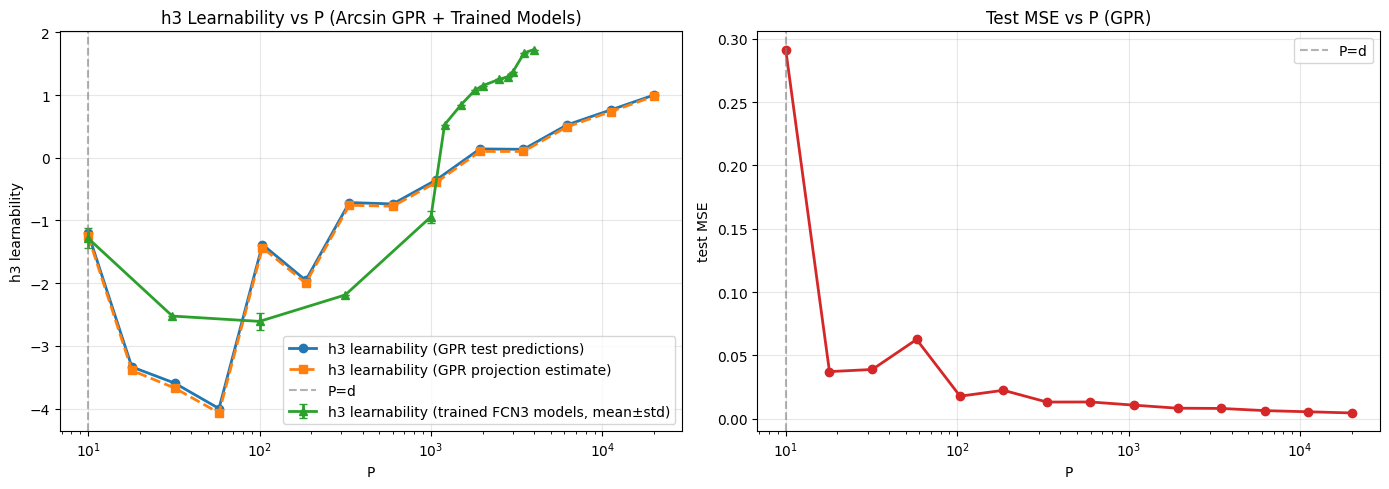

In [35]:
from pathlib import Path
import json
import re
import sys

P_arr = np.array([r['P'] for r in results])
h3_proj_arr = np.array([r['h3_learnability_proj'] for r in results])
h3_test_arr = np.array([r['h3_learnability_test'] for r in results])
mse_arr = np.array([r['mse_test'] for r in results])


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'lib').exists() and (p / 'milestones').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from {start}')


def load_run_config(run_dir: Path) -> dict:
    cfg_path = run_dir / 'config.json'
    if cfg_path.exists():
        with open(cfg_path, 'r') as f:
            return json.load(f)

    m = re.search(
        r"d(?P<d>\d+)_P(?P<P>\d+)_N(?P<N>\d+)_chi(?P<chi>[-+]?\d*\.?\d+)_kappa(?P<kappa>[-+]?\d*\.?\d+)",
        run_dir.parent.name,
    )
    if not m:
        raise FileNotFoundError(f'No config.json and unrecognized run name: {run_dir}')
    return {
        'd': int(m.group('d')),
        'P': int(m.group('P')),
        'N': int(m.group('N')),
        'chi': float(m.group('chi')),
        'kappa': float(m.group('kappa')),
        'activation': 'erf',
    }


def find_checkpoint_file(run_dir: Path) -> Path:
    for name in ('model_final.pt', 'model.pt', 'checkpoint.pt'):
        p = run_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(f'No checkpoint in {run_dir}')


def normalize_state_dict(state):
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    if isinstance(state, dict) and 'state_dict' in state and 'W0' not in state:
        state = state['state_dict']
    if 'W0' in state and hasattr(state['W0'], 'ndim') and state['W0'].ndim == 4:
        state['W0'] = state['W0'].squeeze(0)
        state['W1'] = state['W1'].squeeze(0)
        state['A'] = state['A'].squeeze(0)
    return state


def collapse_model_prediction(y_pred_raw: torch.Tensor) -> torch.Tensor:
    if y_pred_raw.ndim == 1:
        return y_pred_raw
    if y_pred_raw.ndim == 2:
        return y_pred_raw.mean(dim=1)
    return y_pred_raw.reshape(y_pred_raw.shape[0], -1).mean(dim=1)


# Load model class from lib/ to mirror semi_empirical_effective_ridge_correction.py
repo_root = find_repo_root(Path.cwd())
lib_path = repo_root / 'lib'
if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))
from FCN3Network import FCN3NetworkActivationGeneric

scan_dir = repo_root / 'milestones' / 'activation_generic_erf_mf_scaling_convergence' / 'd10_P_scan_kappa_0.1'
checkpoint_files = list(scan_dir.glob('**/seed*/model.pt')) + list(scan_dir.glob('**/seed*/model_final.pt'))
seed_dirs = sorted({p.parent.resolve() for p in checkpoint_files if p.is_file()})

model_rows = []
if len(seed_dirs) == 0:
    print(f'No model checkpoints found under {scan_dir}')
else:
    print(f'Found {len(seed_dirs)} model runs under {scan_dir}')

for run_dir in seed_dirs:
    try:
        cfg_run = load_run_config(run_dir)
        ckpt = find_checkpoint_file(run_dir)

        d_run = int(cfg_run['d'])
        n1v = cfg_run.get('N', cfg_run.get('n1', cfg_run.get('n')))
        if n1v is None:
            continue
        n1 = int(n1v)
        n2 = int(cfg_run.get('n2', n1))
        P_run = int(cfg_run['P'])
        ens = int(cfg_run.get('ens', 1))
        activation = str(cfg_run.get('activation', 'erf')).lower()

        model = FCN3NetworkActivationGeneric(d_run, n1, n2, P_run, ens=ens, activation=activation, device=device).to(device)
        state = torch.load(ckpt, map_location=device)
        state = normalize_state_dict(state)
        model.load_state_dict(state)
        model = model.float().eval()

        # Use the same test set used for GPR curve in this notebook for fair overlay.
        with torch.no_grad():
            y_model_raw = model(X_test.to(dtype=torch.float32))
            y_model = collapse_model_prediction(y_model_raw)

        h3_model = h3_learnability_on_test(y_model, X_test)
        model_rows.append({'P': P_run, 'h3_model': float(h3_model)})
    except Exception as exc:
        print(f'Skipping {run_dir}: {exc}')

model_P = None
model_h3_mean = None
model_h3_std = None
if len(model_rows) > 0:
    by_P = {}
    for row in model_rows:
        by_P.setdefault(int(row['P']), []).append(float(row['h3_model']))
    model_P = np.array(sorted(by_P.keys()))
    model_h3_mean = np.array([np.mean(by_P[p]) for p in model_P])
    model_h3_std = np.array([np.std(by_P[p], ddof=0) for p in model_P])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(P_arr, h3_test_arr, 'o-', lw=2, label='h3 learnability (GPR test predictions)')
ax1.plot(P_arr, h3_proj_arr, 's--', lw=2, label='h3 learnability (GPR projection estimate)')
if model_P is not None:
    ax1.errorbar(
        model_P,
        model_h3_mean,
        yerr=model_h3_std,
        fmt='^-',
        lw=2,
        capsize=3,
        label='h3 learnability (trained FCN3 models, mean±std)'
    )
ax1.axvline(d, color='gray', ls='--', alpha=0.6, label='P=d')
ax1.set_xscale('log')
ax1.set_xlabel('P')
ax1.set_ylabel('h3 learnability')
ax1.set_title('h3 Learnability vs P (Arcsin GPR + Trained Models)')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(P_arr, mse_arr, 'o-', lw=2, color='tab:red')
ax2.axvline(d, color='gray', ls='--', alpha=0.6, label='P=d')
ax2.set_xscale('log')
ax2.set_xlabel('P')
ax2.set_ylabel('test MSE')
ax2.set_title('Test MSE vs P (GPR)')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()